# Análisis Exploratorio de Datos (EDA)

En esta sección del notebook se realiza un análisis exploratorio para el dataset de detección de obstáculos en interiores conformado, abarcando los siguientes pasos: 

**Estructura del EDA:**

* **Paso 1:** Unificación de Datasets base
* **Paso 2:** Análisis Técnico del Dataset (resolución, integridad, duplicados, estadísticas de píxeles)
* **Paso 3:** Distribución de Clases (conteos, co-ocurrencia, comparación train/val/test)
* **Paso 4:** Geometría de Bounding Boxes (tamaño, aspect ratio, heatmap espacial, anchors optimizados)
* **Paso 5:** Complejidad de Escena (densidad de objetos, oclusión/IoU)
* **Paso 6:** Inspección Visual Cualitativa (muestreo aleatorio, detección de anomalías)

In [1]:
# Auto-reload: recarga módulos automáticamente al detectar cambios en disco
%load_ext autoreload
%autoreload 2

# Librerías
import os
import sys
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import cv2
import random
import hashlib
import yaml
from pycocotools.coco import COCO
from sklearn.cluster import KMeans
from pathlib import Path
import zipfile

# Rutas base
base_dir = "/Users/admin/Documents/TFM_UNIR/01_ING_DATOS"

# Añadir path de utilidades
src_path = os.path.join(base_dir, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)
from utils_eda import *

# Directorio de salida para guardar reportes
output_dir = os.path.join(base_dir, "Reports", "EDA_Dataset_OIDC_original_v2")

## Paso 1: Descomprimir Dataset y Mapear Imágenes

En este paso se toma el Dataset **Indoor Object Detection Custom** *-versión original-* en archivo ZIP con formato YOLO26, se descomprime y se prepara para su análisis.

ℹ️ Este dataset Versión Original cuenta con 1074 fotos, a partir de 5 sub-dataset:

- **Dataset_Custom_1**: 512 Fotos tomadas desde ESP32S3 + CAM OV5640 a resolución FRAMSIZE_QVGA 320x240 pixeles [baja iluminación - noche] 

- **Dataset_Custom_2**: 265 Fotos tomadas desde ESP32S3 + CAM OV5640 a resolución FRAMSIZE_SVGA 800x600 pixeles [iluminación media - día] 

- **Dataset_Custom_3:** 213 Fotos tomadas desde ESP32S3 + CAM OV5640 a resolución FRAMSIZE_SVGA 800x600 pixeles [Variabilidad de escenarios reales] Sin preprocesados ni augmentaciones.  

- **Dataset_Custom_4:** 32 Fotos sintéticas generadas con GEMINI PRO NANO BANANA a resoluciones variables [espacios libres + variabilidad de escenarios e iluminación] 

- **Dataset_Custom_5:** 104 Fotos sintéticas generadas con GEMINI PRO NANO BANANA a resoluciones variables [espacios libres + variabilidad de escenarios e iluminación]

El proceso realizado es:

  1. Descomprime el ZIP del dataset original.
  2. Lee data.yaml de cada dataset → extrae clases locales.
  2. Normaliza nombres de clases (lowercase + singular + excepciones).
  3. Construye mapeo global unificado de clases.
  4. Mueve imágenes y reescribe labels con el nuevo class_id.
  5. Genera data.yaml unificado + log de trazabilidad + análisis de distribución.


In [3]:
# Ruta de carpeta para descomprimir el dataset 
dataset_path = os.path.join(base_dir, "Datasets", "dataset_IODC_original_2")

# Descomprimir el Dataset
unzip_datasets(source_dir=dataset_path)

Se encontraron 1 archivos .zip
--------------------------------------------------

Descomprimiendo: Indoor Object Detection Custom.v2-version-original.yolo26.zip
Destino: Indoor Object Detection Custom.v2-version-original.yolo26/
✓ Completado - 2251 archivos extraídos

Proceso completado


🔧 Procesamiento de Dataset YOLO
   📂 Origen:  /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_2/dataset_IODC_original_2
   📂 Destino: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_2

📂 Fase 1: Descubrimiento de clases...

   📋 Mapeo global unificado:
      0: dog
      1: door
      2: obstacle
      3: person
      4: stair

   Total de clases únicas: 5

   📊 Traducción de clases:
      0:'dog' → 0:'dog' (sin cambio)
      1:'door' → 1:'door' (sin cambio)
      2:'obstacle' → 2:'obstacle' (sin cambio)
      3:'person' → 3:'person' (sin cambio)
      4:'stair' → 4:'stair' (sin cambio)

📁 Fase 2: Creando estructura de destino...
   ✅ /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_2/data/images
   ✅ /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_2/data/labels

🚚 Fase 3: Procesando imágenes y labels...
   Splits encontrados: ['train']
   ✅ train: 1124 imágenes procesadas

  

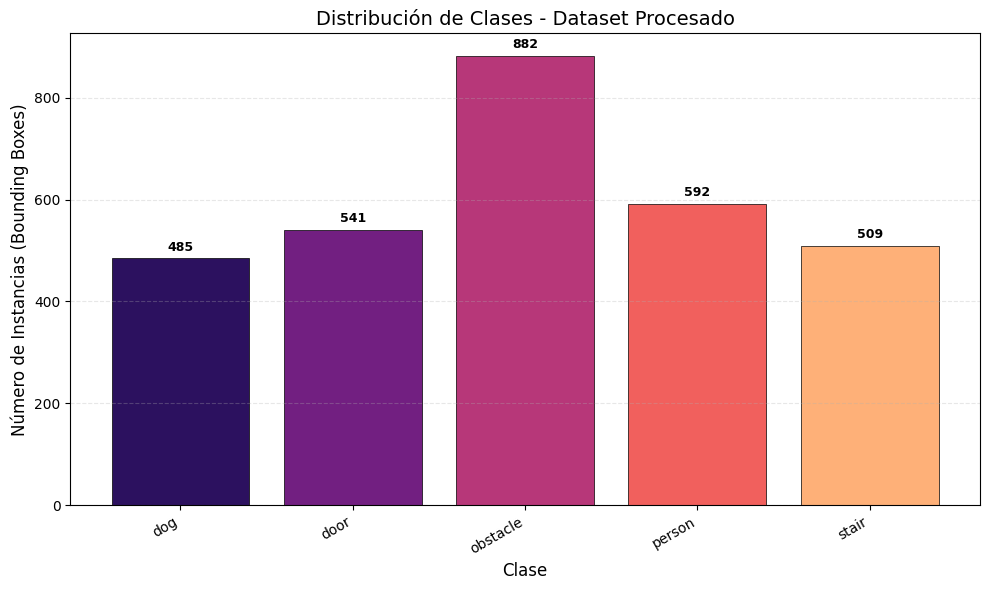


   💾 Gráfica guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/class_distribution.png

✅ PROCESAMIENTO COMPLETADO
   📂 Directorio: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Datasets/dataset_IODC_original_2
   🖼  Imágenes:  1,124
   🏷  Clases:    5 → ['dog', 'door', 'obstacle', 'person', 'stair']
   📦 BB totales: 3,009



In [4]:
# Ruta del dataset descomprimido (con data.yaml + train/images + train/labels)
dataset_path_unzip = os.path.join(dataset_path, "dataset_IODC_original_2")

# 1. Procesar dataset YOLO: normalizar clases, serializar imágenes, reestructurar a data/images + data/labels
stats = process_yolo_dataset(
    dataset_path=dataset_path_unzip,
    output_dir=dataset_path,
    class_overrides={"escalator": "stair"},
    output_dir_reports=output_dir
)

## Paso 2: Análisis Técnico del Dataset

Antes de analizar el contenido semántico del dataset, es fundamental verificar la calidad técnica de los datos a nivel de archivos e imágenes.

**Dataset:** `dataset_maestro_unificado` (dataset unificado, sin división en splits train/valid/test).

**Objetivos:**

1. **Analizar resoluciones:** Verificar consistencia de dimensiones de imágenes.
2. **Sanity checks de integridad:**
   - Archivos corruptos o ilegibles
   - Formatos incorrectos (RGBA, grayscale cuando se espera RGB)
   - Duplicados exactos dentro del dataset (contamination)
3. **Estadísticas de píxeles:** Calcular **mean y std por canal RGB** para normalización del modelo.
4. **Distribución de intensidad:** Analizar histogramas RGB para identificar necesidades de augmentation (brightness, contrast).

**Impacto en el entrenamiento:**
- Imágenes con resoluciones inconsistentes requieren redimensionamiento uniforme.
- Duplicados pueden causar overfitting artificial.
- Channel statistics son **críticas** para la normalización en PyTorch/TensorFlow.

In [5]:
# Cargar dataset YOLO como objeto COCO
coco, img_dir = load_yolo_as_coco(dataset_path)
splits = {'all': coco}
img_dir_map = {'all': img_dir}
print(f"✅ Dataset unificado cargado: {len(coco.getImgIds())} imágenes, {len(coco.getAnnIds())} anotaciones")

# Variables de interés para análisis de geometría y complejidad
target_cat_ids = coco.getCatIds()
id_to_name = {cat['id']: cat['name'] for cat in coco.loadCats(target_cat_ids)}
print(f"🏷️  Clases encontradas: {list(id_to_name.values())}")

# Asignar colores automáticamente a cada clase
_color_pool = [
    (255, 0, 0),      # Rojo
    (0, 255, 0),      # Verde
    (0, 0, 255),      # Azul
    (255, 255, 0),    # Cyan/Amarillo
    (255, 0, 255),    # Magenta
    (0, 255, 255),    # Amarillo (BGR)
]
class_colors = {name: _color_pool[i % len(_color_pool)] for i, name in enumerate(id_to_name.values())}
print(f"🎨 Colores asignados: {class_colors}")

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
✅ Dataset YOLO cargado como COCO:
   📂 Imágenes: 1124
   📝 Anotaciones: 3009
   🏷️  Categorías: ['dog', 'door', 'obstacle', 'person', 'stair']
✅ Dataset unificado cargado: 1124 imágenes, 3009 anotaciones
🏷️  Clases encontradas: ['dog', 'door', 'obstacle', 'person', 'stair']
🎨 Colores asignados: {'dog': (255, 0, 0), 'door': (0, 255, 0), 'obstacle': (0, 0, 255), 'person': (255, 255, 0), 'stair': (255, 0, 255)}



🎨 Generando histogramas de distribución de píxeles...
💾 Histogramas guardados: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/02_rgb_histograms.png


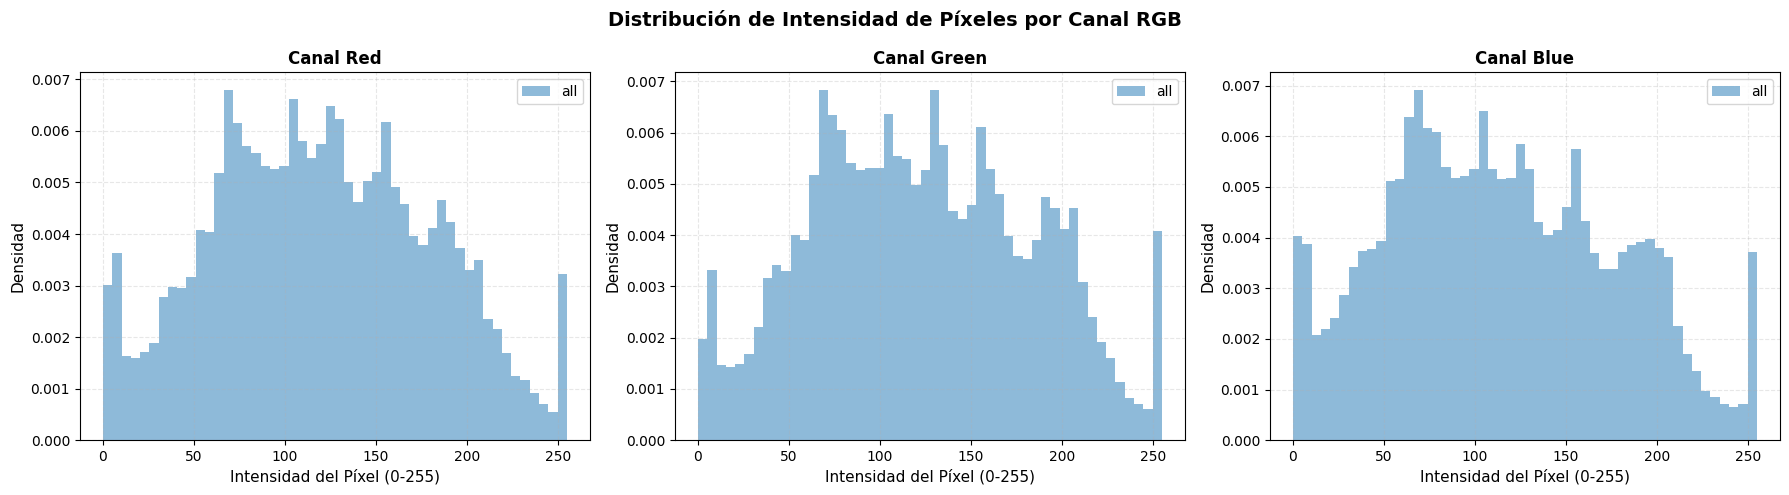

In [6]:
# 2. Visualizar distribución de intensidad de píxeles por canal RGB
plot_channel_histograms(splits, base_dir, sample_size=100, img_dir_map=img_dir_map,
                        output_dir=output_dir, filename='02_rgb_histograms', title='Distribución de Intensidad de Píxeles por Canal RGB')

In [7]:
# 3. Calcular estadísticas de canales RGB para normalización del modelo
df_pixel_stats = calculate_pixel_statistics(splits, base_dir, sample_size=100,
                                            img_dir_map=img_dir_map,
                                            output_dir=output_dir, filename='03_channel_stats')


📊 Calculando estadísticas de canales RGB...
   ALL: RGB mean=[0.4557, 0.4776, 0.4432], std=[0.2281, 0.2341, 0.2410]
💾 Estadísticas guardadas: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/03_channel_stats.csv


In [8]:
# 4. Detectar imágenes duplicadas dentro del dataset usando hash MD5
df_duplicates = detect_duplicates_across_splits(splits, base_dir, img_dir_map=img_dir_map,
                                                output_dir=output_dir, filename='04_duplicates')

display(df_duplicates.head())

# Visualizar muestra de imágenes duplicadas
if len(df_duplicates) > 0:
    dup_img_ids = df_duplicates['image_id'].unique().tolist()
    sample_size = min(8, len(dup_img_ids))
    sample_dup = random.sample(dup_img_ids, sample_size)
    print(f"🔍 Mostrando {sample_size} imágenes duplicadas de {len(dup_img_ids)} encontradas")
    visualize_sample(coco, target_cat_ids, id_to_name, class_colors, img_dir,
                    img_ids=sample_dup, output_dir=output_dir, filename='04b_duplicate_samples', title='Ejemplos de Imágenes Duplicadas')
else:
    print("✅ No hay imágenes duplicadas para visualizar")


🔍 Calculando hashes MD5 de todas las imágenes...
✅ No se encontraron duplicados entre splits


""


✅ No hay imágenes duplicadas para visualizar


In [9]:
# 5. Verificar integridad de archivos de imagen
df_integrity = check_file_integrity(splits, base_dir, img_dir_map=img_dir_map,
                                    output_dir=output_dir, filename='05_integrity_check')


✅ Verificación de Integridad: SIN PROBLEMAS
   Todas las imágenes son válidas y legibles (RGB)


/Users/admin/Documents/TFM_UNIR/01_ING_DATOS/src/utils_eda.py:1685: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  unique_resolutions = df_dims.groupby('split').apply(


💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/06_resolution_scatter.png
💾 Tabla de resoluciones guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/06_resolution_scatter_table.csv


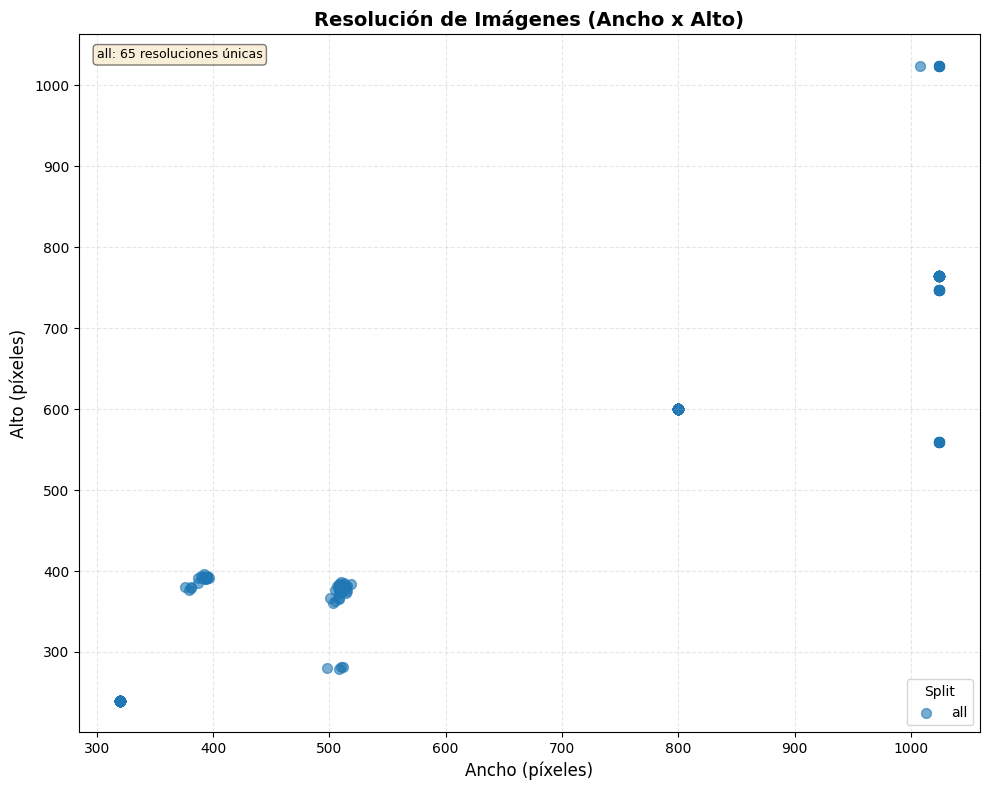

In [10]:
# 6. Extraer dimensiones de todas las imágenes
df_dimensions = get_image_dimensions(splits)
plot_resolution_scatter(df_dimensions, output_dir=output_dir, filename='06_resolution_scatter', title='Resolución de Imágenes (Ancho x Alto)')

## Paso 3: Análisis de Distribución de Clases

En esta etapa se decide qué clases se conservan basándose en su representatividad y relevancia estadística.

* **Conteo de Instancias por Categoría:**
    * **Objetivo:** Identificar clases "minoritarias" que el modelo no aprenderá bien.
* **Imágenes por Categoría vs. Objetos por Categoría:**
    * **Objetivo:** Determinar si una clase está bien distribuida en el dataset o si aparece concentrada en pocas imágenes.
* **Matriz de Co-ocurrencia:**
    * **Objetivo:** Analizar qué objetos aparecen juntos para entender el contexto (ej. la relación entre "Mesa" y "Silla").


In [11]:
# Usar dataset unificado completo para análisis de clases
print(f"✅ Usando dataset unificado para análisis de clases: {len(coco.getImgIds())} imágenes")

✅ Usando dataset unificado para análisis de clases: 1124 imágenes


💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/07_category_distribution.png


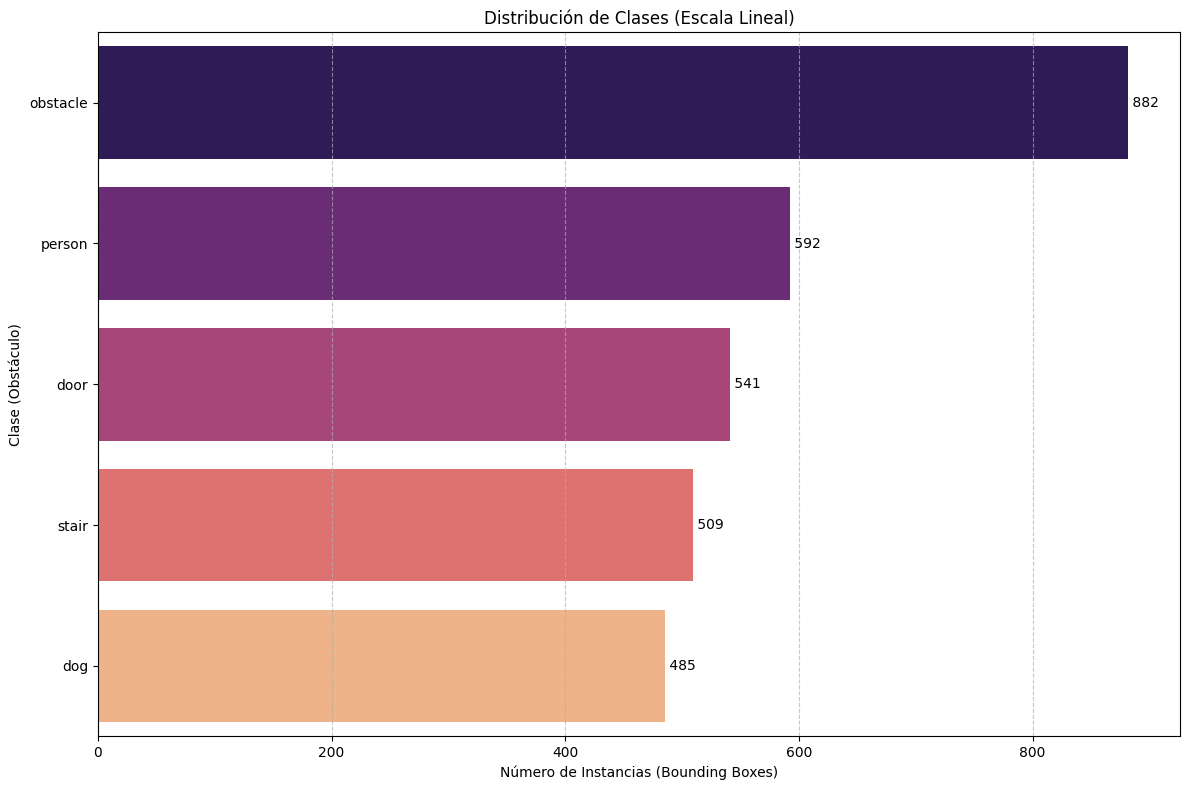


--- Tabla de Distribución ---
| Category   |   Count |
|:-----------|--------:|
| obstacle   |     882 |
| person     |     592 |
| door       |     541 |
| stair      |     509 |
| dog        |     485 |
💾 Tabla guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/07_category_distribution.csv


In [12]:
# 7. Obtener categorías y conteos
cat_ids = [cat['id'] for cat in coco.loadCats(coco.getCatIds())]
df_counts = get_category_distribution(coco)
plot_category_distribution(df_counts, scale_type='linear', palette='magma', 
                          output_dir=output_dir, filename='07_category_distribution', title='Distribución de Clases (Escala Lineal)')

💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/08_image_object_density.png


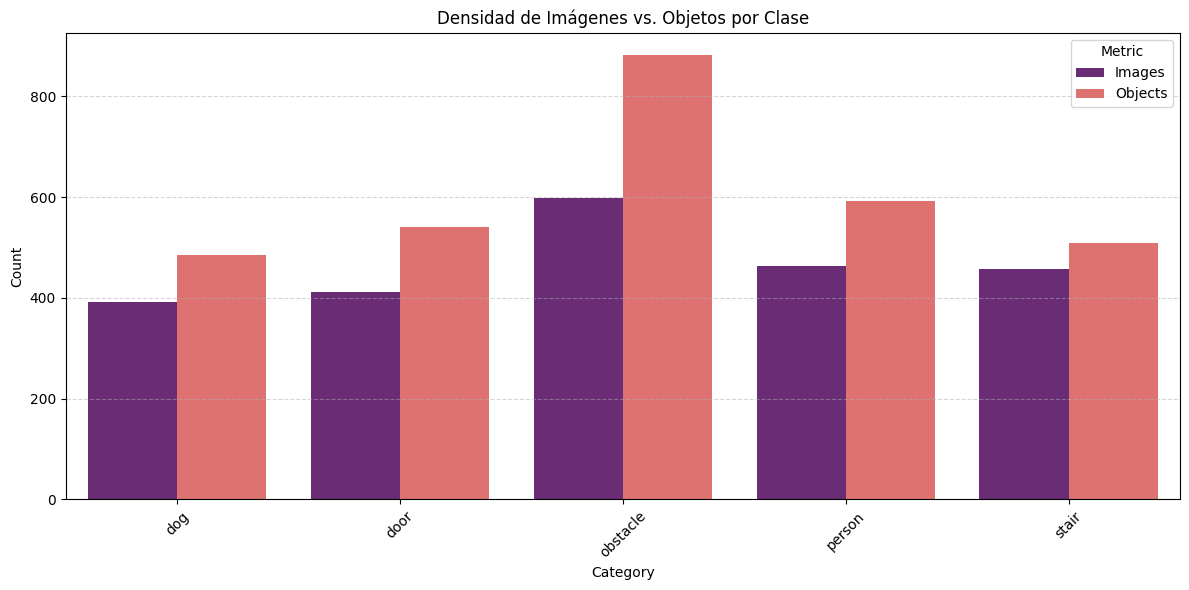

In [13]:
# 8. Obtener Densidad de Imágenes VS. Objetos 
df_density, active_cat_ids = calculate_image_object_density(coco, cat_ids)
plot_image_object_density(df_density, palette='magma',
                         output_dir=output_dir, filename='08_image_object_density', title="Densidad de Imágenes vs. Objetos por Clase")

💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/09_cooccurrence_matrix.png
💾 Matriz guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/09_cooccurrence_matrix.csv


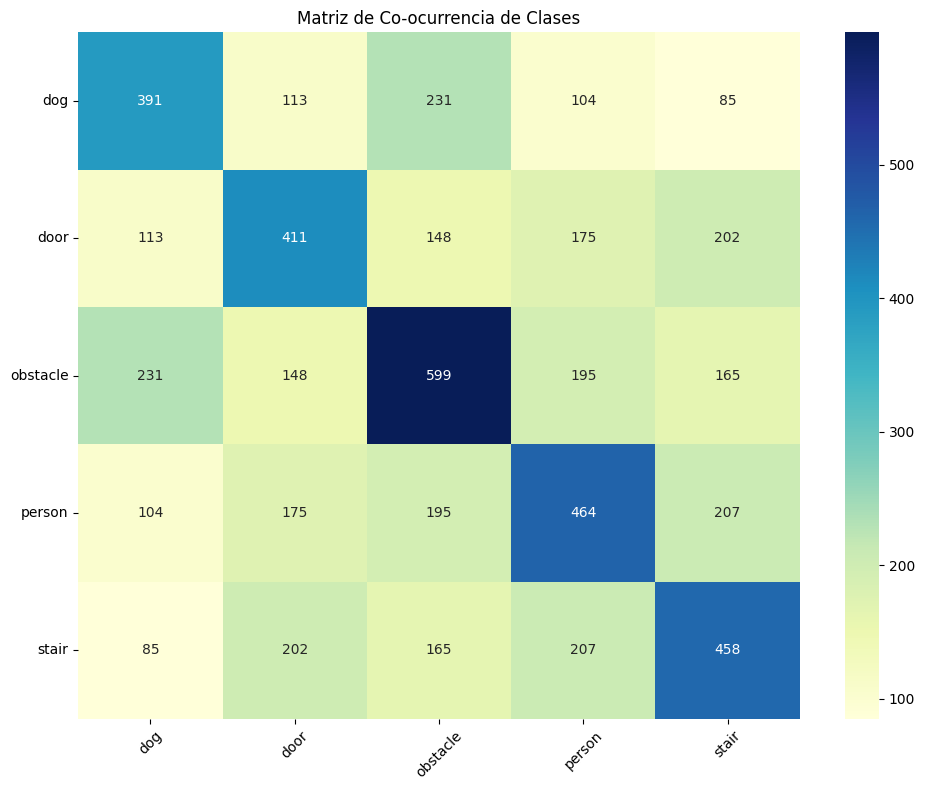

In [14]:
# 9. Obtener Matriz de Co-ocurrencia
co_occurrence_matrix, cat_labels = calculate_cooccurrence_matrix(coco, active_cat_ids)
plot_cooccurrence_matrix(co_occurrence_matrix, cat_labels, cmap='YlGnBu',
                        output_dir=output_dir, filename='09_cooccurrence_matrix', title='Matriz de Co-ocurrencia de Clases')


--- Ratio de Densidad (Promedio de objetos por imagen donde aparece la clase) ---
| Category   |   Images |   Objects |   Ratio |
|:-----------|---------:|----------:|--------:|
| obstacle   |      599 |       882 |  1.4725 |
| door       |      411 |       541 |  1.3163 |
| person     |      464 |       592 |  1.2759 |
| dog        |      391 |       485 |  1.2404 |
| stair      |      458 |       509 |  1.1114 |
💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/10_density_ratio.png
💾 Tabla guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/10_density_ratio.csv


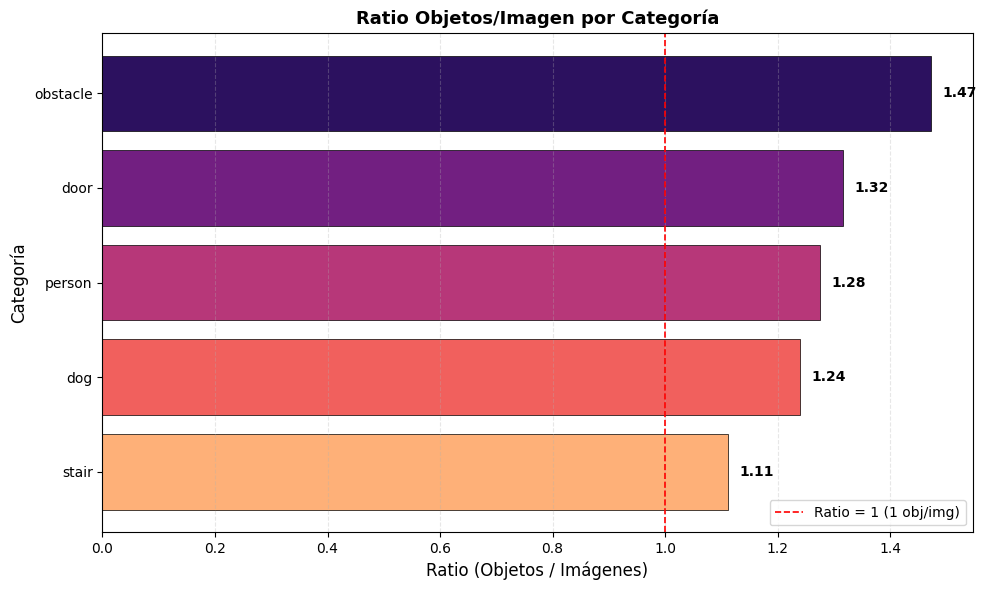

In [15]:
# 10. Calcular ratio Objetos/Imagen por categoría
df_ratio = calculate_and_plot_density_ratio(df_density, palette='magma',
                                            output_dir=output_dir, filename='10_density_ratio', title='Ratio Objetos/Imagen por Categoría')

## Paso 4: Análisis Geométrico de Bounding Boxes

* **Distribución de Tamaños (Área):**
    * **Objetivo:** Clasificar objetos en **Pequeños**, **Medianos** y **Grandes** (Estándar COCO).

* **Relación de Aspecto (Aspect Ratio):**
    * **Objetivo:** Graficar ancho vs. alto.

* **Posición Espacial (Heatmap):**
    * **Objetivo:** Mapa de calor de los centros de las cajas.

* **Optimización de Anchors:**
    * **Objetivo:** Calcular anchors óptimos usando K-Means clustering sobre dimensiones de bboxes.


In [16]:
# 11. Extraer geometría usando función modular
df_geo = extract_bbox_geometry(coco, target_cat_ids,
                               output_dir=output_dir, filename='11_bbox_geometry')


📐 Geometría de Bounding Boxes extraída: 3009 anotaciones
| Category   |   Count |   Area_mean |   Area_median |   Ratio_mean |   Ratio_std |
|:-----------|--------:|------------:|--------------:|-------------:|------------:|
| dog        |     485 |     38819.1 |       11056   |         1.04 |        0.5  |
| door       |     541 |     60072.5 |       37585.2 |         0.44 |        0.22 |
| obstacle   |     882 |     39128.3 |       19168   |         0.75 |        0.38 |
| person     |     592 |     47895.2 |       32768.8 |         0.5  |        0.26 |
| stair      |     509 |     59968.1 |       39005.9 |         1.21 |        0.52 |
💾 Geometría guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/11_bbox_geometry.csv
💾 Resumen guardado: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/11_bbox_geometry_summary.csv


💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/12_size_distribution.png


<Figure size 1000x600 with 0 Axes>

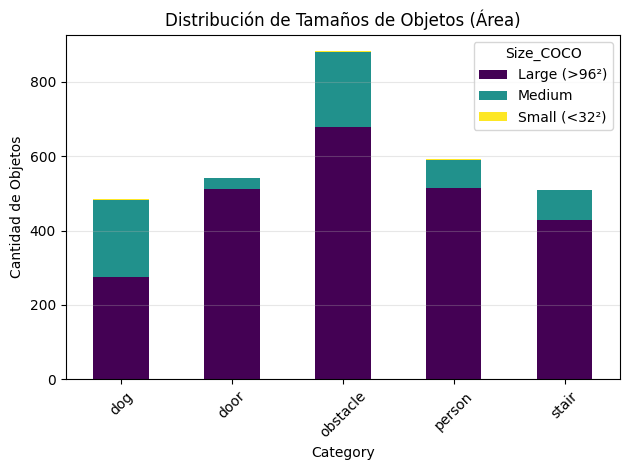


--- Porcentaje de Tamaños por Clase ---
| Category   |   Large (>96²) |   Medium |   Small (<32²) |
|:-----------|---------------:|---------:|---------------:|
| dog        |          56.49 |    42.68 |           0.82 |
| door       |          94.64 |     5.36 |           0    |
| obstacle   |          76.87 |    23.02 |           0.11 |
| person     |          86.82 |    12.84 |           0.34 |
| stair      |          84.09 |    15.91 |           0    |
💾 Tabla guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/12_size_distribution_percentages.csv


In [17]:
# 12. Visualizar la Distribución de Tamaños COCO 
plot_size_distribution(df_geo, colormap='viridis',
                     output_dir=output_dir, filename='12_size_distribution', title='Distribución de Tamaños de Objetos (Área)')

/Users/admin/Documents/TFM_UNIR/01_ING_DATOS/src/utils_eda.py:1018: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_geo, x='Category', y='Ratio', palette=palette)


💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/13_aspect_ratio.png


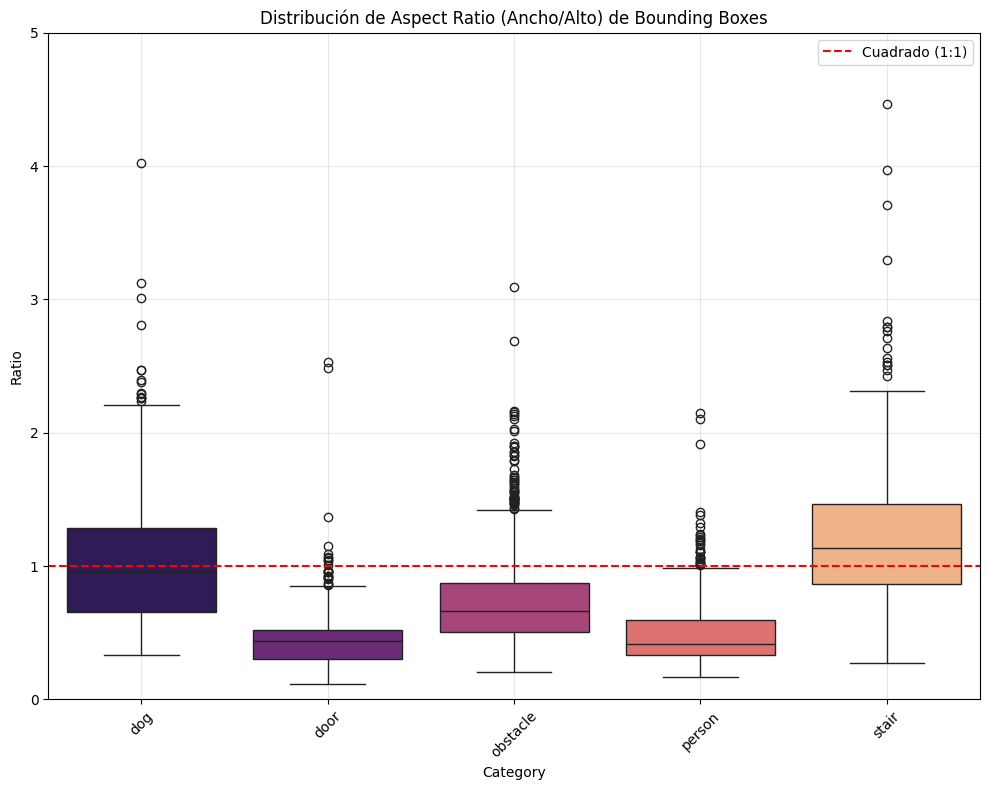

In [18]:
# 13. Visualizar el Aspect Ratio
plot_aspect_ratio(df_geo, palette='magma',
                output_dir=output_dir, filename='13_aspect_ratio', figsize=(10, 8), title='Distribución de Aspect Ratio (Ancho/Alto) de Bounding Boxes')

💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/14_spatial_heatmap.png


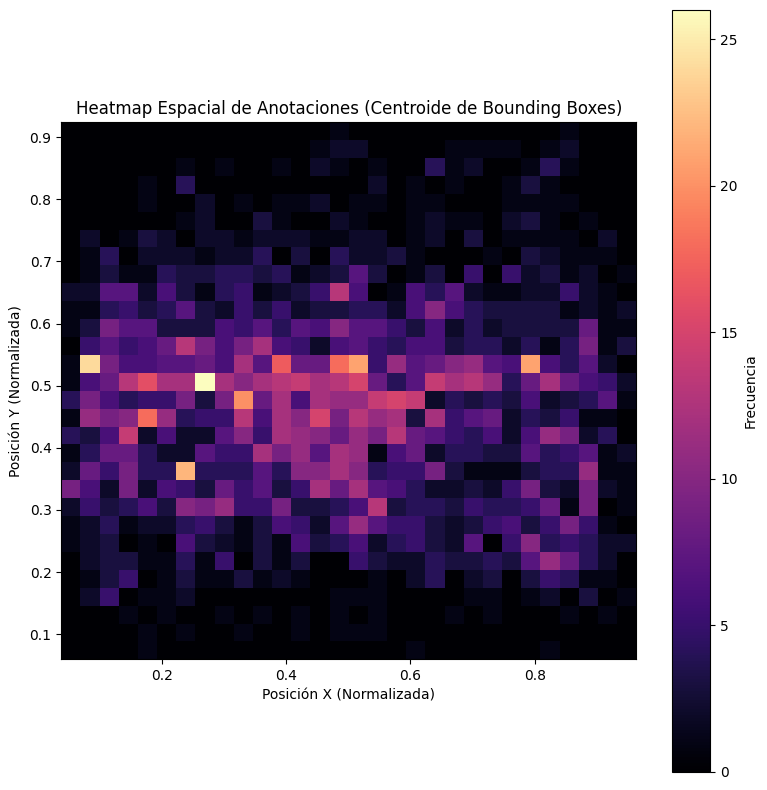

In [19]:
# 14. Visualizar el Heatmap Espacial
plot_spatial_heatmap(df_geo, cmap='magma',
                   output_dir=output_dir, filename='14_spatial_heatmap', title='Heatmap Espacial de Anotaciones (Centroide de Bounding Boxes)')

In [20]:
# 15. Extraer dimensiones normalizadas de todos los bboxes
bbox_dims = extract_bbox_dimensions(coco, target_cat_ids)

print(f"\n📦 Total de bounding boxes extraídos: {len(bbox_dims)}")
print(f"   Dimensiones: ancho y alto normalizados [0,1]")


📦 Total de bounding boxes extraídos: 3009
   Dimensiones: ancho y alto normalizados [0,1]



🔬 Ejecutando K-Means con 8 clusters sobre 3009 bboxes...
✅ Anchors optimizados calculados
💾 Visualización de anchors guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/16_anchor_clusters.png


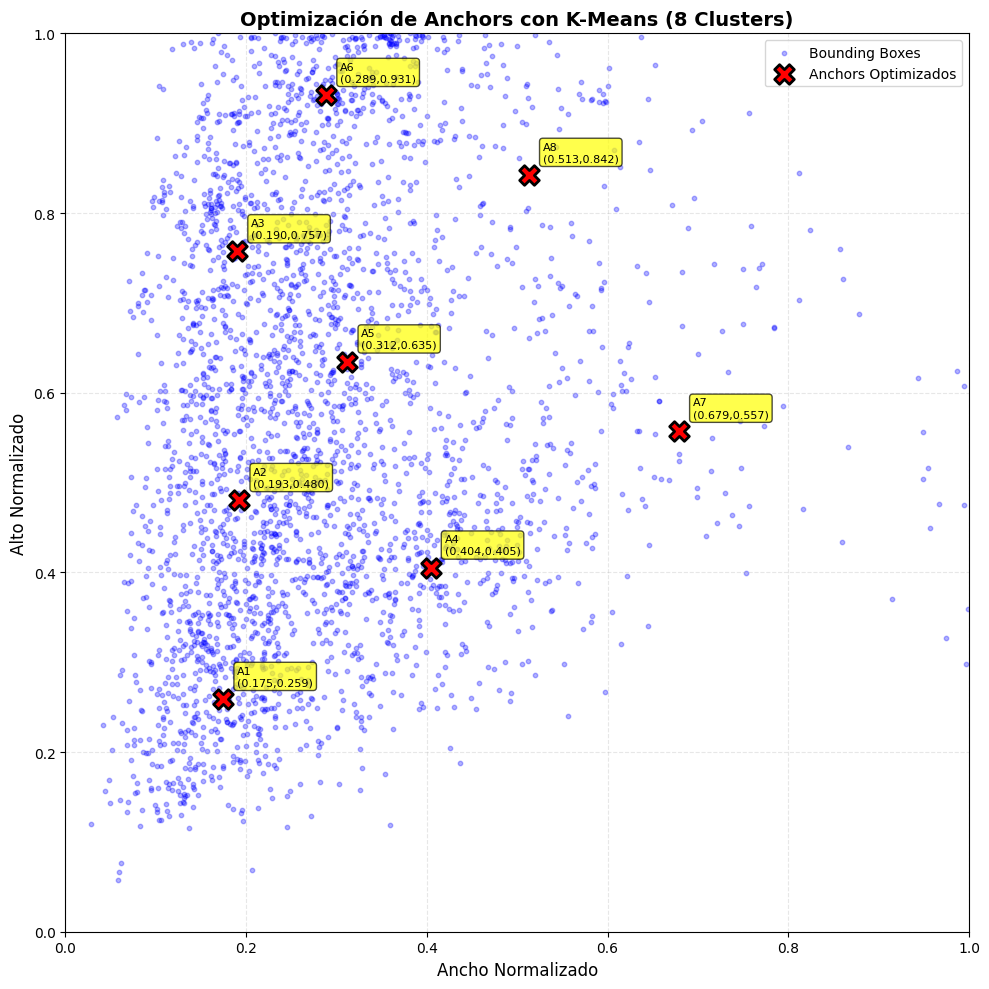

In [21]:
# 16. Calcular y visualizar anchors óptimos usando K-Means
optimal_anchors = kmeans_anchor_optimization(bbox_dims, n_anchors=8, random_state=42)
plot_anchor_clusters(bbox_dims, optimal_anchors, output_dir=output_dir, 
                    filename='16_anchor_clusters', title='Optimización de Anchors con K-Means (8 Clusters)')

In [22]:
# 17. Exportar configuración YAML con Anchors optimizados
export_yolo_anchors(optimal_anchors, img_size=640, output_dir=output_dir, 
                   filename='17_yolo_anchors')


⚙️  Configuración de Anchors para YOLO:
   Imagen: 640x640
   Anchors P3/8 (pequeños): [[111, 165], [123, 307]]
   Anchors P4/16 (medianos): [[121, 484], [258, 259]]
   Anchors P5/32 (grandes): [[199, 406], [184, 595], [434, 356], [328, 539]]
💾 Configuración YAML guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/17_yolo_anchors.yaml
   Usar en modelo: copiar anchors a tu archivo de configuración YOLO


## Paso 5: Complejidad de la Escena

Determina la carga computacional y la dificultad técnica del entrenamiento.

* **Objetos por Imagen (Densidad):**
    * **Objetivo:** Histograma de cantidad de objetos por foto.
    * **Impacto:** Imágenes vacías ayudan a reducir falsos positivos; imágenes muy densas requieren más memoria GPU.
* **Superposición (Occlusión):**
    * **Objetivo:** Calcular el **IoU (Intersection over Union)** entre cajas.
    * **Impacto:** Si hay mucha superposición, se requiere un ajuste fino del *Non-Maximum Suppression (NMS)*.

Procesando imágenes para calcular IoU y Densidad...
💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/17_density_histogram.png


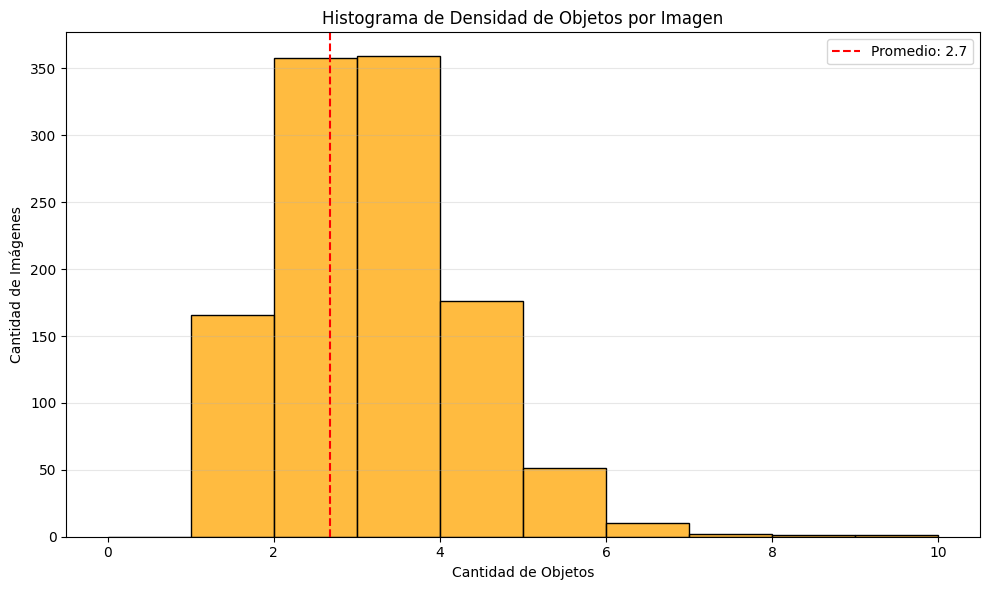

In [23]:
# 17. Visualizar Histograma de Densidad
img_ids = coco.getImgIds()
density_counts, ious = calculate_density_and_iou(coco, target_cat_ids)
plot_density_histogram(density_counts, color='orange',
                     output_dir=output_dir, filename='17_density_histogram', title='Histograma de Densidad de Objetos por Imagen')

💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/18_iou_histogram.png


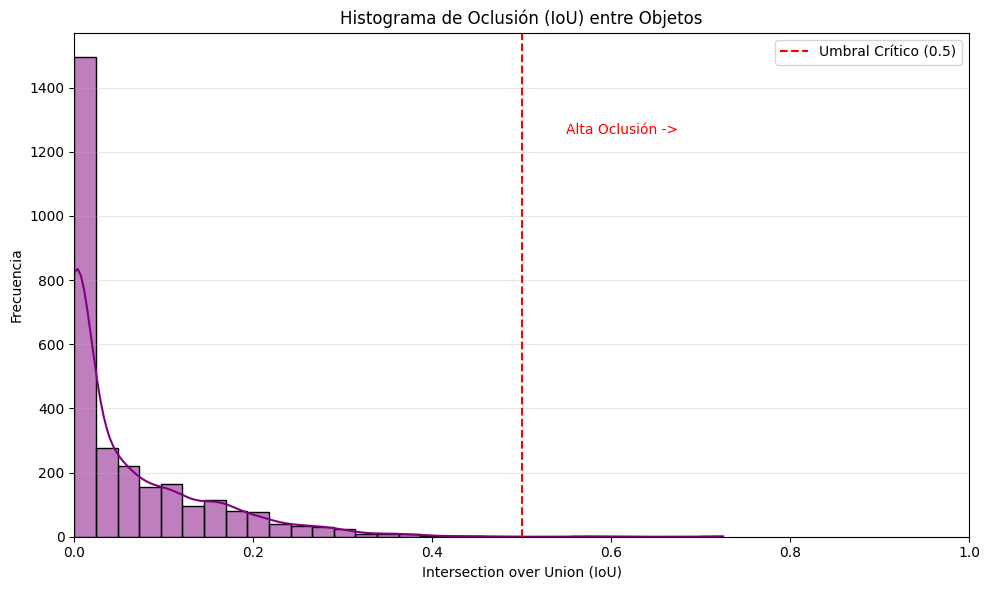

In [24]:
# 18. Visualizar Histograma de Oclusión (IoU)
plot_iou_histogram(ious, color='purple',
                 output_dir=output_dir, filename='18_iou_histogram', title='Histograma de Oclusión (IoU) entre Objetos')

In [25]:
# 19. Resumen numérico de Densidad
print_density_stats(img_ids, density_counts,
                  output_dir=output_dir, filename='19_density_stats')

Total Imágenes Analizadas: 1124
Imágenes Vacías (Background): 0
Promedio de objetos por imagen: 2.68
Máximo de objetos en una imagen: 9
💾 Estadísticas guardadas: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/19_density_stats.csv


## Paso 6: Inspección Visual Cualitativa (Sanity Check)

Validación manual para asegurar la calidad de la información.

1.  **Visualización Randomizada:** Renderizar imágenes con sus etiquetas para confirmar la coherencia de las clases elegidas.
2.  **Verificación de "Ruido":** Identificar errores de etiquetado, como cajas que cubren toda la imagen o que son de tamaño minúsculo.

💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/20_visual_sample_1.png


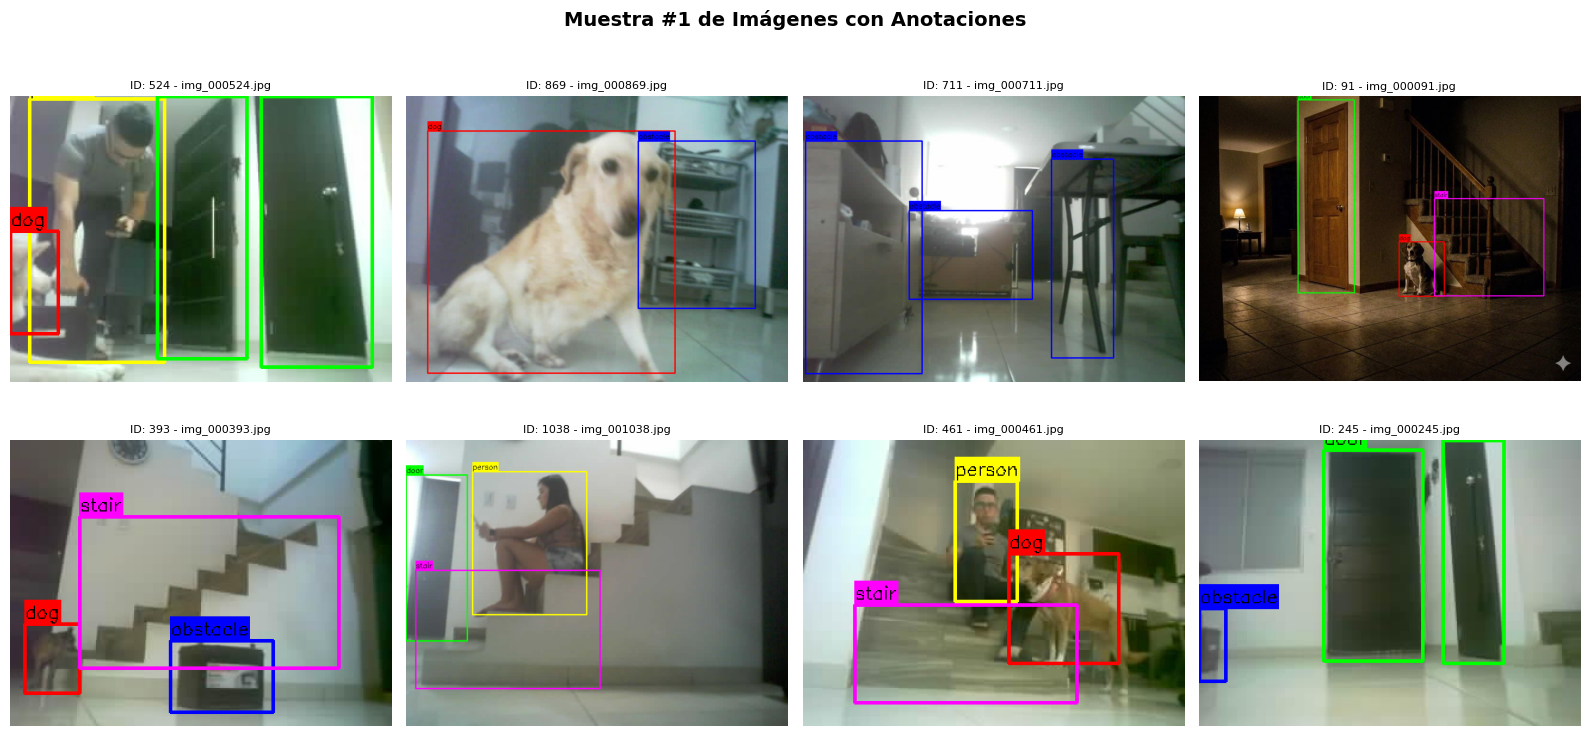

In [26]:
# 20. Visualizar Sample de Imágenes
visualize_sample(coco, target_cat_ids, id_to_name, class_colors, img_dir, num_samples=8,
               output_dir=output_dir, filename='20_visual_sample_1', title='Muestra #1 de Imágenes con Anotaciones')

💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/21_visual_sample_2.png


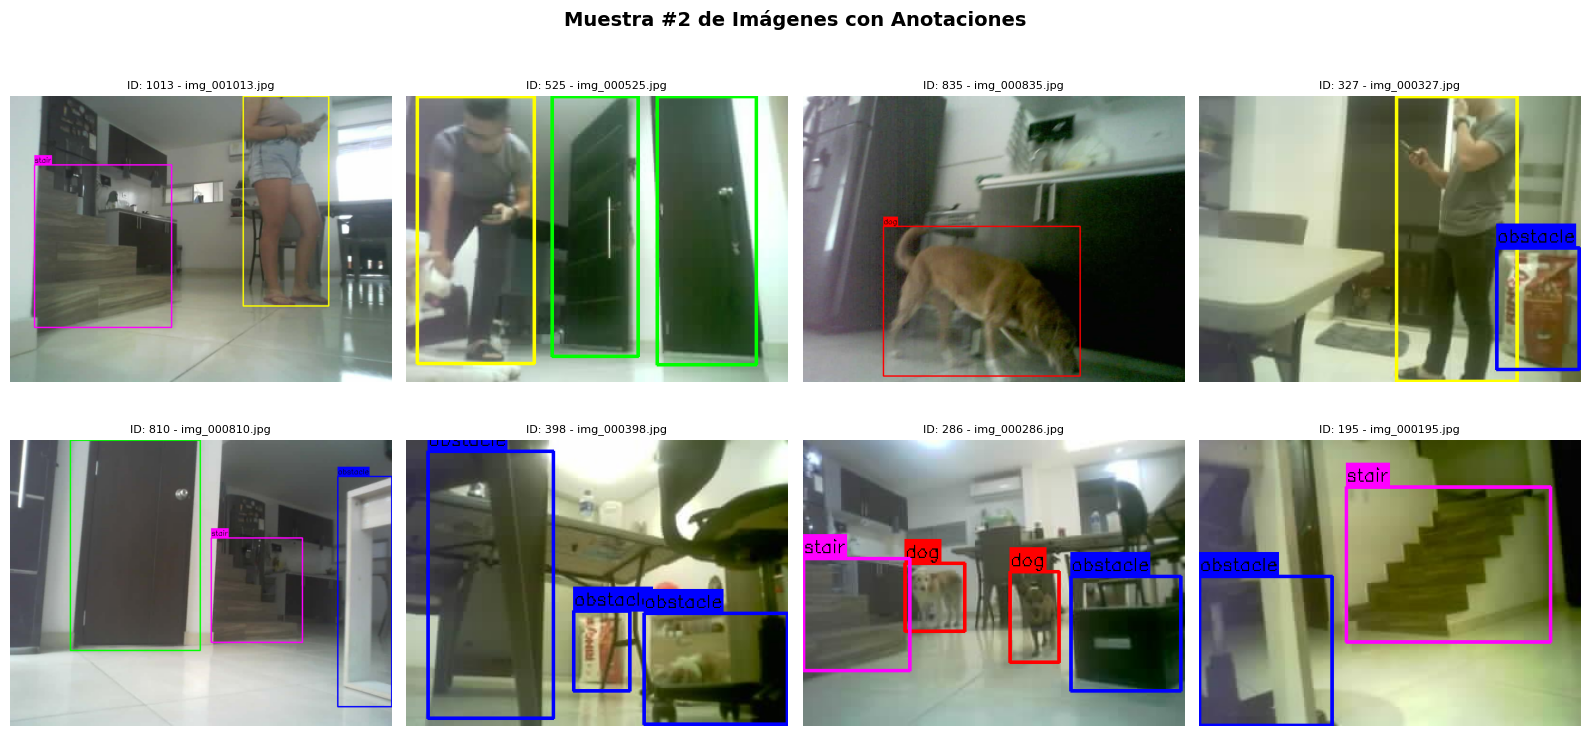

In [27]:
# 21. Visualizar Sample de Imágenes
visualize_sample(coco, target_cat_ids, id_to_name, class_colors, img_dir, num_samples=8,
               output_dir=output_dir, filename='21_visual_sample_2', title='Muestra #2 de Imágenes con Anotaciones')

💾 Figura guardada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Reports/EDA_Dataset_OIDC_original_v2/22_visual_sample_3.png


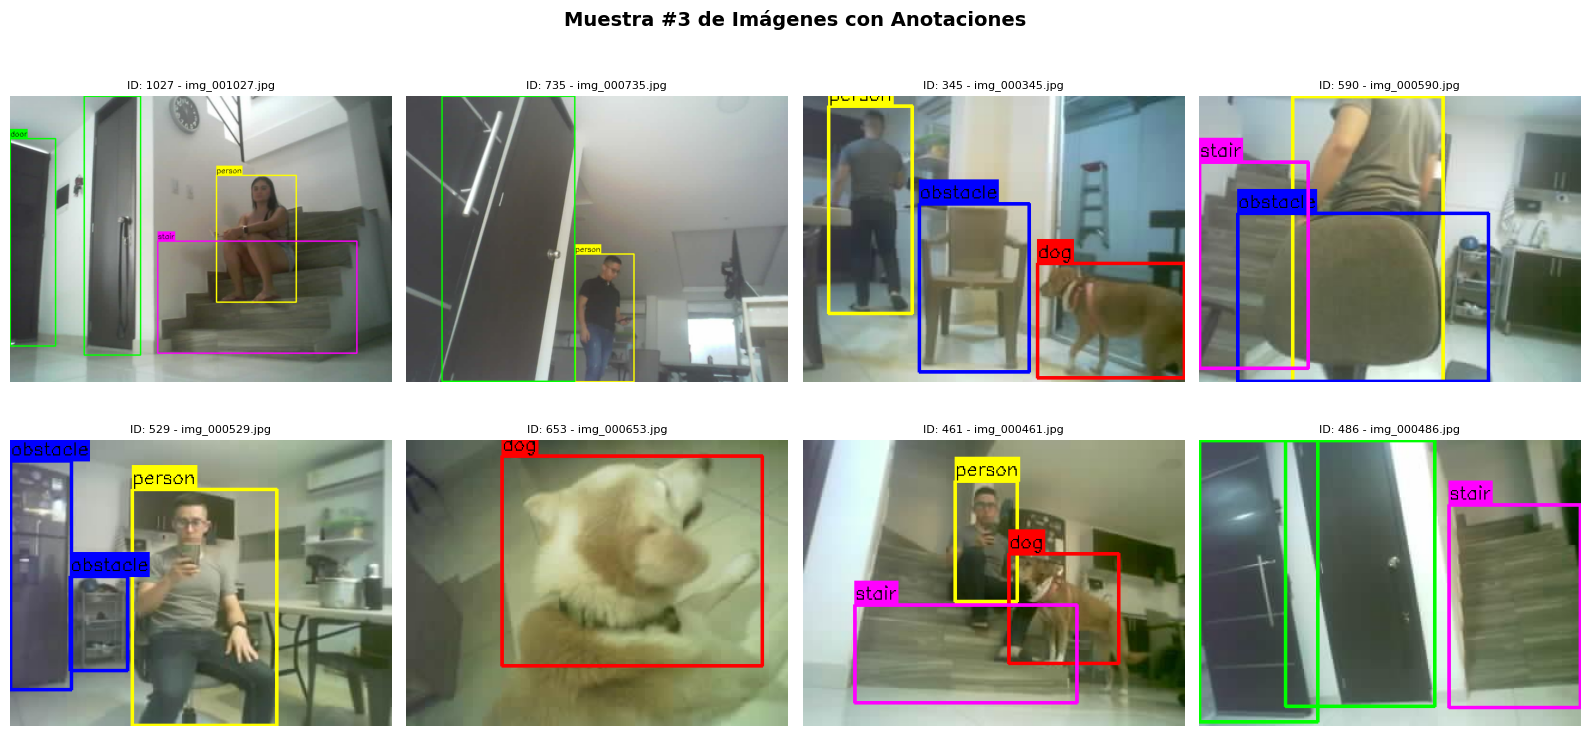

In [28]:
# 22. Visualizar Sample de Imágenes
visualize_sample(coco, target_cat_ids, id_to_name, class_colors, img_dir, num_samples=8,
               output_dir=output_dir, filename='22_visual_sample_3', title='Muestra #3 de Imágenes con Anotaciones')

In [29]:
# 23. Detectar anomalías 
suspect_tiny, suspect_huge = detect_anomalies(coco, target_cat_ids, id_to_name, min_area=225, max_ratio=0.95,
                                             output_dir=output_dir, filename='23_anomalies')

--- Iniciando búsqueda de anomalías ---

Resultados del escaneo:
⚠️ Cajas Minúsculas (<15x15px): 0

⚠️ Cajas Gigantes (>95.0% imagen): 0


In [30]:
# 24. Visualizar imágenes anómalas de cajas minúsculas
if len(suspect_tiny) > 0:
    print("\n Ejemplos de imágenes anómalas: con cajas minúsculas")
    unique_tiny_ids = list(set([s['img_id'] for s in suspect_tiny]))
    sample_size = min(8, len(unique_tiny_ids))  # Máximo 8 imágenes en grilla 4x2
    sample_tiny = random.sample(unique_tiny_ids, sample_size)
    
    # Usar grilla de visualize_sample para mostrar múltiples imágenes
    visualize_sample(coco, target_cat_ids, id_to_name, class_colors, img_dir, 
                    img_ids=sample_tiny, output_dir=output_dir, filename='24_anomaly_tiny', title='Ejemplos de Anomalías: Cajas Minúsculas')

In [31]:
# 25. Visualizar imágenes anómalas con cajas gigantes 
if len(suspect_huge) > 0:
    print("\n Ejemplos de imágenes anómalas: con cajas gigantes")
    unique_huge_ids = list(set([s['img_id'] for s in suspect_huge]))
    sample_size = min(8, len(unique_huge_ids))  # Máximo 8 imágenes en grilla 4x2
    sample_huge = random.sample(unique_huge_ids, sample_size)
    
    # Usar grilla de visualize_sample para mostrar múltiples imágenes
    visualize_sample(coco, target_cat_ids, id_to_name, class_colors, img_dir, 
                    img_ids=sample_huge, output_dir=output_dir, filename='25_anomaly_huge', title='Ejemplos de Anomalías: Cajas Gigantes')

## Síntesis del EDA: Dataset Indoor Object Detection Custom (IODC) v2 Original

La siguiente tabla resume los hallazgos críticos del Análisis Exploratorio de Datos del dataset IODC v2 original (pre-augmentation), sus implicaciones técnicas para un sistema de navegación robótica basado en ESP32-S3 (TinyML) y las acciones correctivas definidas.

| Paso del EDA | Tarea Realizada | Hallazgos Clave | Implicaciones Técnicas | Acción a realizar en Preprocesado | Acción a considerar en Entrenamiento |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Paso 1 | **#1.** Procesamiento y visualización de la distribución de clases del dataset IODC v2 original | 5 clases, 3,009 anotaciones en 1,124 imágenes. Distribución moderadamente equilibrada: obstacle (882, 29.3%) lidera; dog (485, 16.1%) es la clase minoritaria. Ratio max/min = 1.82:1. Solo se encontró split único "all" (sin val/test). | El desbalance es leve (ratio <2:1). No se espera sesgo severo del modelo. Aun así, obstacle casi duplica a dog, y para navegación robótica, dog (agente biológico impredecible) requiere recall alto. | Aplicar augmentation uniforme y considerar leve oversampling de dog. Realizar split train/val/test al no existir particiones previas. | Monitorear mAP per-class. Class weights inversamente proporcionales a frecuencia pueden ser opcionales dado el bajo desbalance, pero se recomienda evaluar su impacto. |
| Paso 2 | **#2.** Visualizar distribución de intensidad de píxeles por canal RGB | Distribución con picos principales en rango 50–150 en los 3 canales. Comportamiento similar entre canales R, G y B. Sin pico pronunciado en 255 (sin sobreexposición sistemática). | La distribución centrada indica escenas de iluminación interior relativamente homogénea. La baja varianza de iluminación podría limitar generalización a condiciones extremas de luz. | Aplicar augmentation de brillo, contraste y gamma para ampliar cobertura del espacio de iluminación y mejorar robustez. | NA |
| Paso 2 | **#3.** Calcular estadísticas de canales RGB para normalización del modelo | Mean RGB = [0.4557, 0.4776, 0.4432], Std RGB = [0.2281, 0.2341, 0.2410]. Media ligeramente inferior a 0.5, std ~0.23 uniforme entre canales. Valores difieren de ImageNet (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) pero son razonablemente próximos. | La normalización es crítica para convergencia. Si se usa transfer learning con backbone preentrenado en ImageNet, usar estadísticas ImageNet; si se entrena from scratch, usar las propias del dataset. | Almacenar mean/std para el pipeline de normalización. | Si transfer learning (recomendado para TinyML): normalizar con estadísticas ImageNet. Si from scratch: usar mean=[0.456, 0.478, 0.443], std=[0.228, 0.234, 0.241]. |
| Paso 2 | **#4.** Detectar imágenes duplicadas usando hash MD5 | ✅ 0 imágenes duplicadas detectadas. Dataset completamente libre de duplicados. | Sin riesgo de data leakage por duplicados. El split train/val/test puede realizarse directamente sin deduplicación previa. Excelente calidad de curación del dataset. | NA (no se requiere deduplicación). | NA |
| Paso 2 | **#5.** Verificar integridad de archivos de imagen | ✅ Todas las 1,124 imágenes son válidas, legibles y en formato RGB. Sin archivos corruptos, truncados ni en formatos inesperados. | No se requiere limpieza de archivos. El pipeline de carga no necesita manejo especial de errores. | NA | NA |
| Paso 2 | **#6.** Extraer dimensiones de todas las imágenes | 65 resoluciones únicas encontradas. Resoluciones variables: desde ~320×240 hasta ~1024×1024, con concentraciones en ~380×390, ~500×370, 800×600 y 1024×750/1024. **No hay resolución uniforme.** | Este dataset original tiene resoluciones heterogéneas. Todas las imágenes necesitarán redimensionamiento para crear batches uniformes. La variedad de resoluciones es positiva para robustez del modelo (entrena con múltiples escalas implícitas). | **Crítico:** Redimensionar todas las imágenes a resolución uniforme (640×640 para YOLO, o 192×192 para TinyML directo). Decidir estrategia: letterbox (preserva aspect ratio) vs resize directo. | Considerar entrenamiento multi-escala aprovechando la diversidad nativa de resoluciones. Para TinyML, progressive resizing (640→320→192) para robustez a baja resolución. |
| Paso 3 | **#7.** Obtener categorías y conteos (distribución detallada) | Confirma distribución: obstacle (882), person (592), door (541), stair (509), dog (485). Las 3 clases top (obstacle, person, door) acumulan 67.0% de las instancias. Las 5 clases están en rango 16.1%–29.3%. | Desbalance bajo. Todas las clases tienen representación suficiente (>480 instancias) para entrenamiento efectivo. La distribución es equilibrada. | Augmentation uniforme; no se requiere augmentation fuertemente diferenciada por clase. | Class weights opcionales. Focal Loss puede no ser necesario dado el bajo desbalance, pero evaluar su efecto en dog/stair. |
| Paso 3 | **#8.** Obtener Densidad de Imágenes vs. Objetos | obstacle: 599 img / 882 obj. person: 464 img / 592 obj. stair: 458 img / 509 obj. door: 411 img / 541 obj. dog: 391 img / 485 obj. Todas las clases aparecen en >34% de las imágenes. | Distribución homogénea: las 5 clases están presentes en un rango similar de imágenes (391–599). No hay clases "raras" confinadas a pocas imágenes. Esto favorece aprendizaje uniforme de todas las clases. | NA | NA |
| Paso 3 | **#9.** Obtener Matriz de Co-ocurrencia | Co-ocurrencia significativa entre clases: obstacle-dog (231 img), person-stair (207 img), door-stair (202 img), obstacle-person (195 img), door-person (175 img), obstacle-stair (165 img). dog es la clase con menor co-ocurrencia con stair (85 img). | Este dataset muestra escenas naturales multi-clase. El modelo aprenderá contextos realistas de co-ocurrencia (e.g., persona+escalera, obstáculo+perro). Favorable para detección contextual. | NA | La co-ocurrencia natural enriquece el aprendizaje contextual. Mosaic augmentation reforzará aún más estas combinaciones. |
| Paso 3 | **#10.** Calcular ratio Objetos/Imagen por categoría | obstacle: 1.47 obj/img, door: 1.32, person: 1.28, dog: 1.24, stair: 1.11. Ratios uniformemente bajos (1.1–1.5). | Escenas con baja densidad por clase: típicamente 1 instancia por clase por imagen. Favorable para hardware limitado (ESP32-S3). NMS será simple al no haber muchas instancias solapadas de la misma clase. | NA | max_detections puede ser conservador (10–15) dado el bajo ratio. NMS threshold estándar (~0.45) será suficiente. |
| Paso 4 | **#11.** Extraer geometría de bounding boxes | 3,009 anotaciones analizadas. door: mayor área media (60,073 px²), stair (59,968). dog es la clase con mayor variabilidad (area_mean=38,819, area_median=11,056, ratio ~3.5:1 entre media y mediana). Aspect ratio: door (0.44, vertical), person (0.50, vertical), obstacle (0.75), dog (1.04, cuadrado), stair (1.21, horizontal). | Gran diversidad de formas. door y person son claramente verticales; stair es horizontal; dog y obstacle son más variables. La discrepancia media/mediana en dog indica distribución sesgada con outliers de área grande. | NA | Usar modelo anchor-free (YOLOv8+, YOLO11) o anchors K-Means optimizados. La heterogeneidad geométrica favorece arquitecturas con FPN/multi-escala. |
| Paso 4 | **#12.** Visualizar la Distribución de Tamaños COCO | Predominancia de objetos Large (>96²): door 94.6%, person 86.8%, stair 84.1%, obstacle 76.9%, dog 56.5%. dog tiene la mayor proporción de Medium (42.7%). Small objects son marginales (<1% en todas las clases). | Dataset dominado por objetos medianos y grandes, coherente con cámaras indoor a corta distancia. dog es la clase más variable en tamaño (casi mitad Large/Medium). Para ESP32-S3 a 192×192, objetos grandes seguirán siendo detectables; los pocos Small se perderán. | NA | Priorizar cabezas P4/P5 (objetos medianos/grandes). P3 (small) puede simplificarse en arquitectura TinyML. dog requiere atención especial por su distribución bimodal de tamaños. |
| Paso 4 | **#13.** Visualizar el Aspect Ratio | door y person tienden a ser verticales (mediana <0.5). dog tiene dispersión moderada (IQR ~0.6–1.3). stair es horizontal con alta dispersión y outliers hasta 4.5. obstacle centrado ~0.7 con outliers hasta 3.1. | La diversidad de aspect ratios confirma necesidad de anchors variados o modelo anchor-free. Para TinyML, la cuantización debe preservar capacidad de detectar formas verticales (puertas, personas) y horizontales (escaleras). | NA | Augmentation de random crop y scaling. Considerar filtrar outliers extremos (ratio >4) si corresponden a errores de anotación. |
| Paso 4 | **#14.** Visualizar el Heatmap Espacial | Concentración de centroides en banda horizontal central (Y: 0.3–0.6), con hot spots puntuales en la zona superior-izquierda. Distribución razonablemente dispersa en el eje X. | La concentración en la franja central-horizontal es coherente con cámara a altura de robot (objetos en el horizonte). Los hot spots podrían indicar composición fotográfica sistemática, pero no es severo. | NA | NA |
| Paso 4 | **#15.** Extraer dimensiones normalizadas de todos los bboxes | 3,009 bounding boxes extraídos con ancho y alto normalizados en rango [0,1]. Paso intermedio para optimización de anchors. | Normalización permite comparar dimensiones independientemente de la resolución (importante dado que este dataset tiene 65 resoluciones distintas). Facilita cálculo de anchors transferibles. | NA | NA |
| Paso 4 | **#16.** Calcular y visualizar anchors óptimos usando K-Means (8 Clusters) | 8 anchors calculados sobre 3,009 bboxes. Rango desde A1 (0.175×0.259) hasta A8 (0.513×0.842). Distribución cubre bien el espacio de dimensiones con clusters de pequeño a grande. Concentración de anchors en zona media (0.2–0.5 ancho). | Los anchors personalizados capturan la distribución específica de este dataset. Relevante solo para modelos anchor-based (YOLOv5, v7). Los 8 clusters cubren adecuadamente las 5 clases con sus diferentes geometrías. | NA | Si modelo anchor-based: integrar estos anchors. Si YOLOv8+/YOLO11 (anchor-free): informativo, confirma distribución de tamaños. |
| Paso 4 | **#17a.** Exportar configuración YAML con Anchors optimizados para 640×640 | Anchors exportados en 3 escalas: P3/8 (pequeños): [111×165], [123×307]; P4/16 (medianos): [121×484], [258×259]; P5/32 (grandes): [199×406], [184×595], [434×356], [328×539]. | YAML listo para configuración YOLO. Anchors cubren desde ~17% hasta ~68% del tamaño de imagen 640×640. Para TinyML, reescalar proporcionalmente a resolución de inferencia. | NA | Copiar a config YOLO si anchor-based. Reescalar si resolución ≠ 640. |
| Paso 5 | **#17b.** Visualizar Histograma de Densidad de objetos por imagen | Distribución centrada con promedio de 2.7 obj/img. Mayoría de imágenes tiene 2–4 objetos. Máximo: ~10 objetos por imagen. Sin outliers extremos. Distribución compacta. | Escenas de complejidad moderada y uniforme (2–4 objetos). Sin outliers extremos (máx ~10). Favorable para ESP32-S3: carga de detección predecible y acotada. | NA | max_detections = 10–15 es suficiente. Batch size y NMS estándar funcionarán sin problemas de memoria. |
| Paso 5 | **#18.** Visualizar Histograma de Oclusión (IoU) entre Objetos | Mayoría de pares con IoU bajo (<0.1), distribución exponencialmente decreciente. Muy pocos casos con IoU >0.3. Prácticamente nulos sobre 0.5 (umbral crítico de alta oclusión). | Baja oclusión generalizada. NMS simple será suficiente en todas las escenas. No se observan pares con IoU ≈ 1.0 (sin anotaciones duplicadas superpuestas). | NA | NMS IoU threshold estándar (~0.45–0.5). Para TinyML, NMS greedy simplificado es viable dado el bajo solapamiento. |
| Paso 5 | **#19.** Resumen numérico de Densidad | 1,124 imágenes analizadas. 0 imágenes vacías (background). Promedio: 2.68 obj/img. Máximo: 9 obj/img. | Sin imágenes background (vacías). Todas las imágenes contienen al menos un objeto. Para reducir falsos positivos, se necesitará generar o incorporar imágenes background artificialmente. El promedio bajo (~2.7 obj/img) es favorable para hardware limitado. | Considerar añadir imágenes negativas (sin objetos) al dataset para reducir falsos positivos del modelo. | Incluir background samples en entrenamiento. Si no se añaden, el modelo podría "alucinar" detecciones en escenas vacías. |
| Paso 6 | **#20, #21, #22.** Visualizar 3 muestras aleatorias de imágenes con anotaciones (Sanity Check) | Las muestras muestran anotaciones visualmente coherentes con bounding boxes bien ajustados. Diversidad de escenarios interiores naturales: habitaciones, pasillos, escaleras, puertas, obstáculos variados. Imágenes con resoluciones variadas confirmando la heterogeneidad dimensional. | Calidad general de anotación aceptable. Las imágenes provienen de escenas interiores reales, lo que favorece la representatividad para el caso de uso del robot navegador. | NA | NA |
| Paso 6 | **#23.** Detectar anomalías en anotaciones | ✅ 0 cajas minúsculas (<15×15px) detectadas. ✅ 0 cajas gigantes (>95% del frame) detectadas. Dataset completamente limpio de anomalías en anotaciones. | Excelente calidad de anotación: sin artefactos de borde, sin bboxes degenerados, sin anotaciones que cubran el frame completo. No se requiere limpieza de anotaciones. | NA (dataset limpio). | NA |
| Paso 6 | **#24, #25.** Visualizar imágenes anómalas | Sin imágenes anómalas para visualizar (0 tiny, 0 huge). | NA | NA | NA |

**🎯 Conclusión Final:**

El dataset IODC v2 original presenta una base de **1,124 imágenes** con resoluciones heterogéneas (65 resoluciones únicas) y **3,009 anotaciones** en **5 clases** relevantes para navegación robótica indoor (obstacle, door, person, stair, dog). La calidad del dataset es alta: sin duplicados, sin archivos corruptos, sin anomalías de anotación, y con distribución de clases moderadamente equilibrada (ratio 1.82:1). Se identifican **3 acciones de preprocesado** antes de entrenar:

1. **Redimensionamiento uniforme (Prioridad ALTA):** Las 65 resoluciones diferentes deben normalizarse a 640×640 (letterbox o resize) para crear batches de entrenamiento uniformes.
2. **Split train/val/test (Prioridad ALTA):** El dataset solo tiene un split único ("all"); es necesario crear particiones val/test estratificadas.
3. **Incorporar imágenes background:** El dataset no contiene imágenes vacías (0 background). Añadir negative samples para reducir falsos positivos en navegación real.

Para el **entrenamiento orientado a TinyML/ESP32-S3**, las principales consideraciones son:
- **Augmentation uniforme** con énfasis en brillo/contraste para compensar la baja variabilidad de iluminación del dataset de fuente única.
- **max_detections ≤ 15** es suficiente dado el máximo de 9 objetos por imagen.
- Priorizar **cabezas P4/P5** (objetos medianos/grandes) y simplificar P3 en la arquitectura TinyML.
- Entrenar con **progressive resizing** (640→320→192) para robustez a baja resolución, aprovechando la diversidad nativa de resoluciones.
- **Class weights opcionales**: el desbalance leve (1.82:1) puede no requerir Focal Loss, pero evaluar su impacto en dog.
- **NMS simplificado (greedy)**: viable dado el bajo solapamiento entre objetos (IoU mayoritariamente <0.1).